# Thermal State Preparation by the Interaction-Based Algorithm
### Fermi-Hubbard model

## 1. Overview
This notebook implements a small-scale interaction-based system-bath algorithm for preparing the thermal state of a Fermi-Hubbard Hamiltonian $H$. 
We refer to the quantum system of interest as the **system**, and the ancillary qubits as the **bath**. The algorithm thermalizes or cools the system through a repeated-interaction framework.

The goal is to drive the system state toward the Gibbs state at the target inverse temperature $\beta$.
At the $n$-th iteration, a fresh bath qubit is prepared, the joint system-bath state evolves under a time-dependent Hamiltonian, and the bath qubit is then traced out. Averaging over the sampled system operator $A$, bath frequency $\omega$, and random sign $s$, one step is described by the induced quantum channel
$$
\rho_{n+1}
=
\Phi(\rho_{n})
=
\mathbb{E}_{A,\omega,s}
\operatorname{Tr}_E
\left[
U_\Gamma(T)
\left(\rho_{n}\otimes \rho_E\right)
U_\Gamma^{\dagger}(T)
\right].
$$
where $\rho_n$ is the system state at the $n$-th iteration, $\rho_E$ is the initial bath state, and $\operatorname{Tr}_E$ denotes the partial trace over the environment. The unitary $U_\Gamma(T)$ is generated by a time-dependent system-bath Hamiltonian. 

One iteration consists of the following steps:

1. Initialize a bath ancilla in the thermal state.
2. Evolve the joint system-bath state for time $T$ under the time-dependent Hamiltonian $H_\Gamma(t)$.
3. Trace out the bath ancilla.
4. Reset the bath and repeat the procedure for the next iteration.


### Implementation Notes

The implementation is based on two main modules:

- `hamiltonians.py` provides routines for constructing the Fermi-Hubbard Hamiltonian and the system coupling operators.
- `channels.py` provides routines for constructing and applying the system-bath interaction channel.

We use `quimb` for spin and tensor-product operators, `numpy`/`scipy` for dense linear algebra, and a few functions from the local files `hamiltonians.py` and `channels.py`.

The functions used below are:

- `hubbard_spinful_fermi`: builds the Fermi-Hubbard Hamiltonian.
- `jw_fermion_ops_flat`: returns Jordan-Wigner fermionic creation/annihilation operators.
- `_expm_from_eigh`: constructs a matrix exponential from an eigendecomposition.
- `f_gaussian`: evaluates the Gaussian pulse $f(t)$.
- `suzuki_trotter_vbasis`: applies the Trotterized joint system-bath evolution.
- `trace_out_last_qubit`: removes the last bath qubit.

In [1]:
import quimb as qu
import numpy as np

import scipy.sparse as sp
from scipy.linalg import expm
from scipy.sparse import coo_matrix
from numpy.polynomial.hermite import hermgauss
import scipy

import random
import matplotlib as mpl # noqa
import matplotlib.pyplot as plt # noqa
from tqdm import tqdm

from hamiltonians import hubbard_spinful_fermi,jw_fermion_ops_flat
from channels import construct_unified_channel,analyze_fixed_point,random_density_orthogonal_to,_expm_from_eigh,f_gaussian,_sym_herm

import warnings
import os
def short_warning(message, category, filename, lineno, line=None):
    return f"{os.path.basename(filename)}:{lineno}: {category.__name__}: {message}\n"
warnings.formatwarning = short_warning


op_kws = {'sparse': True, 'stype': 'coo'}
ikron_kws = {'sparse': True, 'stype': 'coo',
             'coo_build': True, 'ownership': None}

## 2. Model and Parmameters
### One-Step Hamiltonian

The unitary $U_\Gamma$ is generated by the time-dependent Hamiltonian

$$
H_{\Gamma}(t)
=
H \otimes \mathbb{I}_E
+
\mathbb{I}_S \otimes H_E(\omega)
+
\Gamma f(t)
\left(
A \otimes B_E
+
A^{\dagger} \otimes B_E^{\dagger}
\right).
$$

Here $H$ is the system Hamiltonian. $H_E(\omega)$ is the bath Hamiltonian with frequency $\omega$.  $\Gamma$ is the coupling strength and $f(t)$ is the filter function. The interaction term includes the system and bath operators $A$ and $B_E$.
- The system operator $A$ is sampled from the set $\mathcal{A}$.
- The frequency $\omega$ is sampled from the distribution $g(\omega)$.
- The sign $s$ is sampled uniformly from $\{\pm 1\}$. 

Repeated applications of $\Phi_\Gamma$ drive the system toward the desired ground state.

Denote the free system-bath Hamiltonian as
$$
H_0
=
H \otimes \mathbb{I}_E
+
\mathbb{I}_S \otimes H_E(\omega),
$$
and the interaction Hamiltonian as
$$
H_I
=
s(A \otimes B)
+
s(A \otimes B)^\dagger,
\qquad s \in \{+1,-1\}.
$$
The joint Hamiltonian becomes 
$$ H_{\Gamma}(t) = H_0 + \Gamma f(t)H_I .$$

### Parameters

We work with a two-site spinful Fermi-Hubbard model. The system Hilbert space dimension is

$$
d_S=4^N=2^{2N}.
$$

- The bath is a single qubit with $$H_E(\omega) = -\frac{\omega}{2} Z,\quad
  B = \frac{X+iY}{2}. $$

- The filter function $ f(t) = \frac{1}{(2\pi)^{1/4}\sigma} \exp\left(-\frac{t^2}{4\sigma^2}\right).$
- The frequency is sampled from the Gaussian distribution
$$
g(\omega)
=
\frac{\beta}{\sqrt{2\pi a_\omega}}
\exp\left[
-\frac{(\beta\omega+1)^2}{2a_\omega}
\right],
\qquad
a_\omega
=
2-\frac{\beta^2}{4\sigma^2}.
$$
- The initial bath state is set to the target temperature. Namely, for thermal-state preparation,
  $\rho_E=
  \frac{
    e^{-\beta H_E(\omega)}
  }{
    \operatorname{Tr}\left(e^{-\beta H_E(\omega)}\right)
  }.
  $
- The one step simulation time $T = 5\sigma$. 
- The parameter $\alpha = \Gamma/\sqrt{\sigma}$.


In [2]:
N=2 #number of sites in the physical model
dsys = 2 ** (2*N) # system dimension
beta = 1 #inverse temperature
sigma = 2 * beta #width of the Gaussian pulse
Ss = 5 * sigma #simulation time in one iteration
dTime = 0.1 #time step size in one iteration
alpha_list = np.array([1, 0.5, 0.25, 0.1, 0.05, 0.01]) / (sigma**0.5) #different choice of alpha
Nstep = 4000 #number of iterations

## 3. Construct the Hamiltonian and the target state
### Fermi-Hubbard Hamiltonian
The system Hamiltonian and operators are constructed using functions from hamiltonians.py. 
$$
H = -t\sum_{j=1}^{L-1} \sum_{\sigma\in\{\uparrow,\downarrow\}} c_{j,\sigma}^\dagger c_{j+1,\sigma}+U\sum_{j=1}^L (n_{j,\uparrow}-\frac{1}{2})(n_{j,\downarrow}-\frac{1}{2})\,.
$$

The system operators are sampled from the fermionic ladder operators produced by `jw_fermion_ops_flat`.

In [ ]:
# fermi hubbard model
Hamsys = hubbard_spinful_fermi(N, t = 1.0, U=-4.0, op_kws=op_kws, ikron_kws=ikron_kws)
Hamsys = Hamsys.toarray()
As_op_array = jw_fermion_ops_flat(N) #sample from fermionic operators

### The target Gibbs state 

In [4]:
rhogibbs = expm(-beta*Hamsys)
rhogibbs = rhogibbs/rhogibbs.trace()
Hamsys0 = Hamsys
Hamsys = qu.kron(Hamsys, qu.eye(2))

_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
_matfuncs.py:358: RuntimeWarning: invalid value encountered in matmul


## 4. Density operator evolution
In one step, we first sample a bath frequency $\omega$ from the Gaussian distribution, choose a system operator $A$ and a random sign $s$ ($sA \in \mathcal{A}$). The evolution operator is
$$
U_\Gamma = \mathcal{T}
\exp\left(
-i\int_{-T}^{T}
\left(H_0+\Gamma f(t)H_I\right)\,dt
\right).
$$
It can be implemented using a second-order Trotter splitting. 
$$
U_\Gamma \approx
\prod_{k}
\left[
e^{-iH_0\Delta t/2}
e^{-i\Gamma f(t_k)H_I\Delta t}
e^{-iH_0\Delta t/2}
\right].
$$





In [11]:
# Initial state: a random pure-state density matrix chosen to have small overlap with the Gibbs state
rhosys = random_density_orthogonal_to(rhogibbs, approx=True)
#simulation loop
fidelity = np.zeros((Nstep+1,len(alpha_list)))
fidelity[0,:] = np.real(np.trace(scipy.linalg.sqrtm(scipy.linalg.sqrtm(rhogibbs) @ rhosys @ scipy.linalg.sqrtm(rhogibbs)))**2)
rhosys_list = [rhosys.copy() for _ in range(len(alpha_list))]
a_freq = 2 - beta**2 / (4 * sigma**2)
omega_mean = -1 / beta
omega_std = np.sqrt(a_freq) / beta
dims = [2] * (2*N+1)

# fix all random seeds for reproducibility 
np.random.seed(50)
random.seed(50)

for i in tqdm(range(Nstep)):

    omega = np.random.normal(loc=omega_mean, scale=omega_std)
    Hambath = -omega * qu.spin_operator('z', **op_kws)
    Hambath = Hambath.toarray()
    rhobath = expm(-beta * Hambath)
    rhobath = rhobath/rhobath.trace()
    Hambath = qu.kron(qu.eye(2**(2*N), **op_kws), Hambath)
    Hambath = Hambath.toarray()

    k = random.randint(0, N-1)
    A = random.choice(As_op_array)
    B = qu.spin_operator('x', **op_kws)+1j*qu.spin_operator('y', **op_kws)
    sign_random = (-1)**(random.randint(0,1))
    interact = sign_random*qu.kron(A,qu.ikron(B, (2,) * 1, 0, **ikron_kws))
    interact += interact.conj().T

    for idx, alpha in enumerate(alpha_list):

        U = np.eye(2**(2*N+1))

        rho = np.kron(rhosys_list[idx], rhobath)

        #  build H0 once per i (dense) 
        H0 = _sym_herm(Hamsys + Hambath)

        # eigendecomp of H0 once → U0_half = exp(-i H0 dt / 2)
        w0, Q0   = np.linalg.eigh(H0)
        U0_half  = _expm_from_eigh(Q0, w0, factor=(-1j * dTime / 2.0))

        #  build interaction V once per i (dense) 
        V   = _sym_herm(interact)

        # eigendecomp of V once → later we reuse to get Uv(amp) fast
        wv, Qv = np.linalg.eigh(V.toarray())

        # precompute the pulse values for this i
        nsub  = 2*round(Ss/dTime) + 1
        tgrid = (np.arange(nsub) * dTime) - Ss
        fvals = np.asarray([f_gaussian(t, sigma) for t in tgrid], dtype=float)

        for k in range(nsub):
            amp = fvals[k] * alpha
            Uv = _expm_from_eigh(Qv, wv, factor=(-1j * amp * dTime))
            dU = U0_half @ Uv @ U0_half

            # U = U @ dU
            U =  dU @ U 

        rho = U  @ rho  @ U.conj().T

        rhosys_list[idx] = qu.ptr(rho, dims, list(range(2*N)))

        fidelity[i+1,idx] = np.real(np.trace(scipy.linalg.sqrtm(scipy.linalg.sqrtm(rhogibbs) @ rhosys_list[idx] @ scipy.linalg.sqrtm(rhogibbs)))**2)


2521061235.py:5: RuntimeWarning: divide by zero encountered in matmul
2521061235.py:5: RuntimeWarning: overflow encountered in matmul
2521061235.py:5: RuntimeWarning: invalid value encountered in matmul
  0%|          | 0/4000 [00:00<?, ?it/s]2521061235.py:60: RuntimeWarning: divide by zero encountered in matmul
2521061235.py:60: RuntimeWarning: overflow encountered in matmul
2521061235.py:60: RuntimeWarning: invalid value encountered in matmul
2521061235.py:63: RuntimeWarning: divide by zero encountered in matmul
2521061235.py:63: RuntimeWarning: overflow encountered in matmul
2521061235.py:63: RuntimeWarning: invalid value encountered in matmul
2521061235.py:65: RuntimeWarning: divide by zero encountered in matmul
2521061235.py:65: RuntimeWarning: overflow encountered in matmul
2521061235.py:65: RuntimeWarning: invalid value encountered in matmul
2521061235.py:69: RuntimeWarning: divide by zero encountered in matmul
2521061235.py:69: RuntimeWarning: overflow encountered in matmul
252

### Convergence of the fidelity

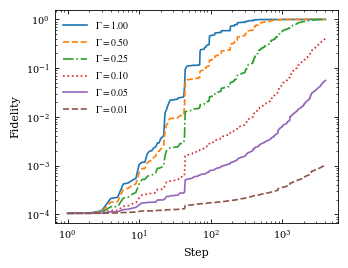

In [10]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
steps = np.arange(Nstep + 1) + 1

fig, ax = plt.subplots(figsize=(3.35, 2.55))

linestyles = ["-", "--", "-.", ":", "-", "--"]

for idx, alpha in enumerate(alpha_list):
    Gamma = alpha * np.sqrt(sigma)
    ax.plot(
        steps,
        fidelity[:, idx],
        linewidth=1.2,
        linestyle=linestyles[idx % len(linestyles)],
        label=fr"$\Gamma={Gamma:.2f}$"
    )

ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)

ax.set_xlabel(r"Step")
ax.set_ylabel(r"Fidelity")

ax.legend(loc="upper left", handlelength=2.4)

fig.tight_layout(pad=0.3)
fig.savefig("figures/hubbard_2_dynamics.pdf", bbox_inches="tight", dpi=300)
plt.show()

The fidelity increases over repeated applications of the channel, indicating that the system is driven toward the target Gibbs state. Larger coupling strengths generally produce faster initial convergence, although very large couplings may eventually deviate from the weak coupling scaling due to higher-order effects.

## 5. The properties of the channel
We can also construct the averaged quantum channel and analyze its fixed point.

In the following codes, we compute two channel-level quantities:

- the fidelity between the channel fixed point and the target Gibbs state;
- the spectral gap of the averaged channel.

In [7]:
sigma_list=[sigma, 2*sigma, 4*sigma]
fidelity_list = np.zeros((len(alpha_list), len(sigma_list)))
spectral_gap_list = np.zeros((len(alpha_list), len(sigma_list)))
for idx, alpha in enumerate(alpha_list):
    for sidx, sigma_t in enumerate(sigma_list):
        print(f"\n=== Running channel for Γ/√σ = {alpha:.2e}, σ = {sigma_t:.2f} ===")
        channel_unified = construct_unified_channel(Hamsys_base=Hamsys0, As_ops=As_op_array, alpha=alpha, beta=beta, sigma=sigma_t, dTime=dTime)
        # Analyze fixed points
        rho_fixed_unified, fidelity_list[idx,sidx], spectral_gap_list[idx,sidx] = analyze_fixed_point(
            channel_unified, "Unified Protocol", rhogibbs)


=== Running channel for Γ/√σ = 7.07e-01, σ = 2.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies:   0%|          | 0/201 [00:00<?, ?it/s]channels.py:120: RuntimeWarning: divide by zero encountered in matmul
channels.py:120: RuntimeWarning: overflow encountered in matmul
channels.py:120: RuntimeWarning: invalid value encountered in matmul
channels.py:121: RuntimeWarning: divide by zero encountered in matmul
channels.py:121: RuntimeWarning: overflow encountered in matmul
channels.py:121: RuntimeWarning: invalid value encountered in matmul
channels.py:130: RuntimeWarning: divide by zero encountered in matmul
channels.py:130: RuntimeWarning: overflow encountered in matmul
channels.py:130: RuntimeWarning: invalid value encountered in matmul
Bath frequencies: 100%|██████████| 201/201 [00:35<00:00,  5.69it/s]
base_linalg.py:596: RuntimeWarning: divide by zero encountered in matmul
base_linalg.py:596: RuntimeWarning: overflow encountered in matmul
base_linalg.py:596: RuntimeWarning: invalid value encountered in matmul



=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-01, σ = 4.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies: 100%|██████████| 201/201 [00:46<00:00,  4.29it/s]



=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-01, σ = 8.00 ===
Constructing unified channel ( β = 1)...


...


=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-03, σ = 4.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies: 100%|██████████| 201/201 [00:45<00:00,  4.40it/s]



=== Unified Protocol Fixed Point Analysis ===

=== Running channel for Γ/√σ = 7.07e-03, σ = 8.00 ===
Constructing unified channel ( β = 1)...


Bath frequencies: 100%|██████████| 201/201 [01:06<00:00,  3.01it/s]


=== Unified Protocol Fixed Point Analysis ===


### The spectral gap

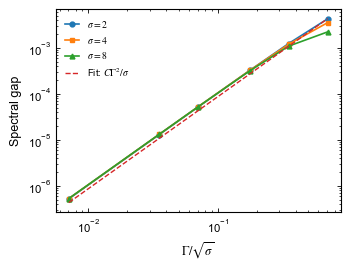

In [8]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def model(alpha, C):
    return C*alpha**2

# Fit the data
popt, pcov = curve_fit(model, alpha_list, spectral_gap_list[:,0])
C_fit = popt[0]
# Generate smooth curve for plotting
alpha_fit = np.linspace(min(alpha_list), max(alpha_list), 200)
gap_fit = model(alpha_fit, C_fit)

markers = ['o', 's', '^', 'D', 'v', 'x', '*', 'p', 'h']

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.35, 2.55))  

for idx, sigma_t in enumerate(sigma_list):
    plt.plot(alpha_list, spectral_gap_list[:, idx],linewidth=1.2,
        label=rf'$\sigma={sigma_t}$', marker=markers[idx], markersize=3.5)

plt.plot(alpha_fit, gap_fit, '--', linewidth=1.0, label=rf'Fit: $C\Gamma^2/\sigma$' )

plt.xlabel(r'$\Gamma/\sqrt{\sigma}$', fontsize=9)
plt.ylabel(r'Spectral gap', fontsize=9)

plt.xscale('log', base=10)
plt.yscale('log', base=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.legend(fontsize=7, loc='upper left', frameon=False, handlelength=1.5)
plt.grid(False)

plt.tight_layout(pad=0.2)

plt.savefig( "figures/Hubbard_2_channel_spectral_gap_Gaussian.pdf", format="pdf", bbox_inches="tight", dpi=300)

plt.show()

## 6. Alternative Implementation: State vector evolution
In this formulation, each trajectory keeps a system state vector. At the beginning of each step, a pure bath state is sampled from the bath Gibbs distribution. After the joint unitary evolution, the bath qubit is measured in the computational basis and the system state is collapsed accordingly. Averaging over many such trajectories recovers the reduced density-matrix dynamics.

This is useful for numerical experiments because the state-vector representation is cheaper than storing density matrices, at the cost of Monte Carlo noise.

In [ ]:
from channels import trace_out_last_qubit, suzuki_trotter_vbasis
eigenvalues, eigenvectors = np.linalg.eigh(Hamsys0)

thermal_energy = np.real(np.trace(rhogibbs @ Hamsys0))

eigvec_bath_0 = np.array([1,0])
eigvec_bath_1 = np.array([0,1])


# eigenbasis of the free system-bath Hamiltonian
Q_se = np.array([np.kron(eigenvectors[:, k], eigvec_bath)
        for k in range(len(eigenvalues))
        for eigvec_bath in (eigvec_bath_0, eigvec_bath_1)])
Q_se = Q_se.T

idx = 0
alpha = alpha_list[idx]
Nstep = 500
Ntraj = 500
energy = np.zeros((Nstep+1,Ntraj))
phi_ini = eigenvectors[:, -1] 
energy[0,:] =  np.real(phi_ini.conj() @ Hamsys0 @ phi_ini)



phi_list = phi_ini.copy()

def sample_thermal_bath_state(omega, beta):
    """
    Sample a pure bath state from the Gibbs state of
    H_E(omega) = -omega S_z.

    The bath energies are -omega/2 for |0> and +omega/2 for |1>.
    """
    energies = np.array([-omega / 2, omega / 2])

    # Numerically stable Gibbs weights
    weights = np.exp(-beta * (energies - np.min(energies)))
    probs = weights / np.sum(weights)

    if random.random() < probs[0]:
        return eigvec_bath_0
    else:
        return eigvec_bath_1

# precompute the Gaussian pulse 
nsub  = 2*round(Ss/dTime) + 1
tgrid = (np.arange(nsub) * dTime) - Ss
fvals = np.asarray([f_gaussian(t, sigma) for t in tgrid], dtype=float)

a_freq = 2 - beta**2 / (4 * sigma**2)
omega_mean = -1 / beta
omega_std = np.sqrt(a_freq) / beta

# bath operator in the interaction term, B
B = qu.spin_operator('x', **op_kws)+1j*qu.spin_operator('y', **op_kws)
for m in tqdm(range(Ntraj), desc="Trajectories"):
    phi_list = phi_ini.copy()
    for i in range(Nstep):
        # Sample bath frequency
        omega = np.random.normal(loc=omega_mean, scale=omega_std)
        phi_bath = sample_thermal_bath_state(omega, beta)
        # Eigenvalues of the free system-bath Hamiltonian
        w_se =  np.array([eigenvalues[k]+eig_bath for k in range(len(eigenvectors))
                          for eig_bath in (-omega/2, omega/2)])
    
        # Randomly choose a system operator
        A = random.choice(As_op_array)
    
        # Construct a Hermitian system-bath interaction
        sign_random = (-1)**(random.randint(0,1))
    
        interact = sign_random*qu.kron(A,qu.ikron(B, (2,) * 1, 0, **ikron_kws))
        interact += interact.conj().T
    
        # Diagonalize the interaction Hamiltonian
        wv, Qv = np.linalg.eigh(interact.toarray())
    
        # Free half-step propagator
        U0_half  = _expm_from_eigh(Q_se, w_se, factor=(-1j * dTime / 2.0))
    
        # Prepare the joint system-bath state
        phi_temp = np.kron(phi_list, phi_bath)
    
        # Evolve the joint state and trace out the bath qubit
        phi_list = trace_out_last_qubit(suzuki_trotter_vbasis(phi_temp, fvals, alpha, dTime, Qv, wv, U0_half))
    
        # Record system energy
        energy[i+1,m] = np.real(phi_list.conj().T @ Hamsys0 @ phi_list)


3143089804.py:4: RuntimeWarning: divide by zero encountered in matmul
3143089804.py:4: RuntimeWarning: overflow encountered in matmul
3143089804.py:4: RuntimeWarning: invalid value encountered in matmul
Trajectories: 100%|██████████| 500/500 [03:34<00:00,  2.33it/s]


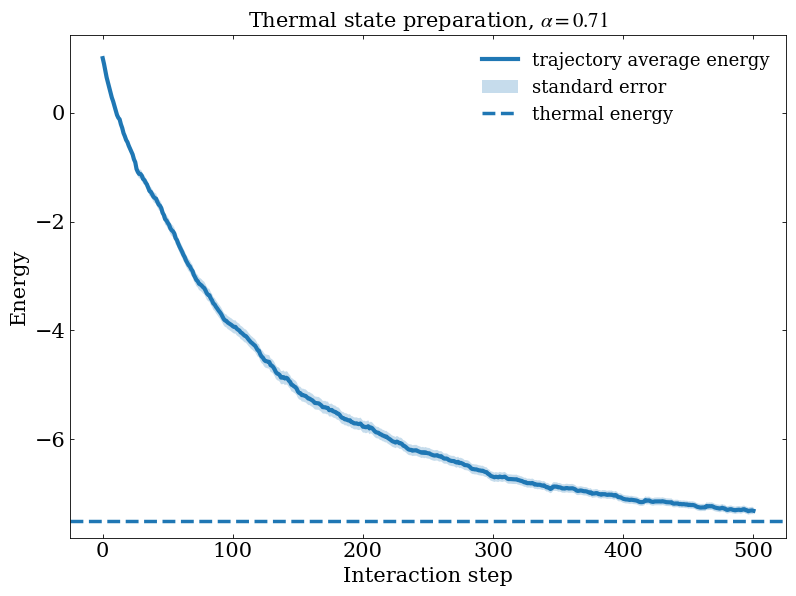

In [31]:
energy_mean = energy.mean(axis=1)
energy_stderr = energy.std(axis=1) / np.sqrt(Ntraj)

steps = np.arange(Nstep + 1)

plt.figure(figsize=(8, 6))

plt.plot(steps, energy_mean, linewidth=3, label="trajectory average energy")
plt.fill_between(steps, energy_mean - energy_stderr, energy_mean + energy_stderr, alpha=0.25, label="standard error")
plt.axhline(thermal_energy, linestyle="--", linewidth=2.5, label="thermal energy")

plt.xlabel("Interaction step", fontsize=15)
plt.ylabel("Energy", fontsize=15)
plt.title(fr"Thermal state preparation, $\alpha = {alpha:.2f}$", fontsize=15)

plt.legend(fontsize=13)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.savefig("figures/Fermi_Hubbard_energy_average.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 7. Explanation on functions

`trace_out_last_qubit`: When we apply the quantum channel $\Phi_\Gamma$ using state vectors, the joint system-bath evolution may entangle the system with the bath. To keep a pure-state trajectory, we measure the bath qubit in the computational basis and return the normalized conditional state of the system.

<!-- Each time, when we implement the quantum channel $\Phi_\Gamma$ on the state vector, we need to ensure the final state can still be expressed as a pure state through a trajectory-level bath measurement routine. We obtain the state by sampling the bath state.  -->

For example, suppose the joint state after the system-bath evolution is 
$$
|\psi_0\rangle\otimes |0\rangle_E
+
|\psi_1\rangle\otimes |1\rangle_E,
$$
The bath measurement probabilities are
$$
p_0=\langle \psi_0|\psi_0\rangle,
\qquad
p_1=\langle \psi_1|\psi_1\rangle,
$$

The function samples an outcome $b\in\{0,1\}$, and returns the normalized conditional system state

$$
|\phi_{\mathrm{new}}\rangle
=
\frac{|\psi_b\rangle}{\sqrt{p_b}}.
$$

